# GBP/USD Session-Level Bias Accuracy Test

## Objective
Test the XGBoost model from `main.py` on **per-session price movement prediction** (Asia, London, New York).

| Parameter | Value |
|---|---|
| **Training window** | 4 years of data |
| **Testing window** | 1 year of data (most recent) |
| **Prediction target** | Session close > session open → Bullish (1), else Bearish (0) |
| **Sessions** | Asia (00:00–07:00 UTC), London (07:00–12:00 UTC), New York (12:00–17:00 UTC) |
| **Model** | XGBoost (same architecture as `main.py`) |
| **Evaluation** | Per-bar accuracy, per-session-instance accuracy, confusion matrices, equity curves |


---
## 1. Setup & Imports

In [3]:
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, brier_score_loss
)
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 60)

# ── CONFIGURATION ──
PAIR = 'GBPUSD'

PATHS = {
    '1D':  'gbpusd_1D.csv',
    '4H':  'gbpusd_4H.csv',
    '1H':  'gbpusd_1H.csv',
    '15M': 'gbpusd_15M.csv',
}

# Session windows (UTC)
ASIA_START   = 0
ASIA_END     = 7
LONDON_START = 7
LONDON_END   = 12
NY_START     = 12
NY_END       = 17

# Train = 4 years, Test = 1 year
TRAIN_YEARS = 4
TEST_YEARS  = 1
RANDOM_STATE = 42

SESSIONS = {
    0: {'name': 'Asia',     'start': ASIA_START,   'end': ASIA_END},
    1: {'name': 'London',   'start': LONDON_START, 'end': LONDON_END},
    2: {'name': 'New York', 'start': NY_START,     'end': NY_END},
}

print(f'Pair: {PAIR}')
print(f'Train: {TRAIN_YEARS} years | Test: {TEST_YEARS} year')
print(f'Sessions: Asia (00-07), London (07-12), New York (12-17) UTC')


Pair: GBPUSD
Train: 4 years | Test: 1 year
Sessions: Asia (00-07), London (07-12), New York (12-17) UTC


---
## 2. Data Loading

In [4]:
def load_ohlc(path: str, timeframe: str) -> pd.DataFrame:
    """Load OHLC CSV, clean placeholders, sort chronologically."""
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    rename_map = {}
    if 'date' in df.columns and 'datetime' not in df.columns:
        rename_map['date'] = 'datetime'
    for tiingo_col, std_col in [('fxOpen', 'open'), ('fxHigh', 'high'),
                                 ('fxLow', 'low'), ('fxClose', 'close')]:
        if tiingo_col in df.columns:
            rename_map[tiingo_col] = std_col
    if rename_map:
        df.rename(columns=rename_map, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values('datetime').reset_index(drop=True)
    df = df.drop_duplicates(subset='datetime')

    # Remove placeholder bars (O=H=L=C)
    mask = ((df['open'] == df['high']) & (df['high'] == df['low']) &
            (df['low'] == df['close']))
    removed = mask.sum()
    if removed > 0:
        print(f"  Removed {removed} placeholder bars from {timeframe}")
    df = df[~mask].reset_index(drop=True)
    df = df.ffill().bfill()
    return df


# Load all timeframes
data = {}
for tf, path in PATHS.items():
    data[tf] = load_ohlc(path, tf)
    print(f'{tf}: {len(data[tf]):>7,} rows  '
          f'({data[tf]["datetime"].min().date()} → {data[tf]["datetime"].max().date()})')


  Removed 2 placeholder bars from 1D
1D:   1,628 rows  (2021-01-03 → 2026-03-31)
  Removed 7 placeholder bars from 4H
4H:   8,380 rows  (2021-01-03 → 2026-03-31)
  Removed 24 placeholder bars from 1H
1H:  32,319 rows  (2021-01-03 → 2026-03-31)
  Removed 86 placeholder bars from 15M
15M: 129,065 rows  (2021-01-03 → 2026-03-31)


---
## 3. Feature Engineering Functions

These are identical to `main.py` — Close-only structure, Delivery state, FVG states, Session context, HTF merge.

In [5]:
def compute_close_only_structure(df: pd.DataFrame, swing_len: int = 5) -> pd.DataFrame:
    """V3 FEATURE A: Close-only market structure on HTFs."""
    df = df.copy()
    closes = df['close']

    df['swing_high_close'] = closes.rolling(swing_len, min_periods=swing_len).max().shift(1)
    df['swing_low_close']  = closes.rolling(swing_len, min_periods=swing_len).min().shift(1)

    prev_swing_h = df['swing_high_close'].shift(swing_len)
    prev_swing_l = df['swing_low_close'].shift(swing_len)

    df['close_hh'] = (df['swing_high_close'] > prev_swing_h).astype(int)
    df['close_hl'] = (df['swing_low_close']  > prev_swing_l).astype(int)
    df['close_lh'] = (df['swing_high_close'] < prev_swing_h).astype(int)
    df['close_ll'] = (df['swing_low_close']  < prev_swing_l).astype(int)

    df['close_trend'] = np.select(
        [(df['close_hh'] == 1) & (df['close_hl'] == 1),
         (df['close_lh'] == 1) & (df['close_ll'] == 1)],
        [1, -1], default=0
    )

    df['close_bos_bull'] = (closes > df['swing_high_close']).astype(int)
    df['close_bos_bear'] = (closes < df['swing_low_close']).astype(int)

    n = len(df)
    last_dir = np.zeros(n)
    dist_bos = np.zeros(n)
    cur_dir = 0
    last_idx = 0
    for i in range(n):
        if df['close_bos_bull'].iat[i] == 1:
            cur_dir = 1; last_idx = i
        elif df['close_bos_bear'].iat[i] == 1:
            cur_dir = -1; last_idx = i
        last_dir[i] = cur_dir
        dist_bos[i] = i - last_idx

    df['last_close_bos_dir']  = last_dir
    df['dist_from_close_bos'] = dist_bos
    df['close_bos_net_10'] = (
        df['close_bos_bull'].rolling(10, min_periods=1).sum() -
        df['close_bos_bear'].rolling(10, min_periods=1).sum()
    )
    return df


In [6]:
def compute_delivery_state(df_15m, df_daily, df_4h):
    """V3 FEATURE B: Delivery-from-liquidity state machine."""
    df = df_15m.copy()
    df['date'] = df['datetime'].dt.date

    daily = df_daily[['datetime', 'high', 'low']].copy()
    daily['date'] = daily['datetime'].dt.date
    daily = daily.sort_values('date')
    daily['pdh'] = daily['high'].shift(1)
    daily['pdl'] = daily['low'].shift(1)
    pdh_map = dict(zip(daily['date'], daily['pdh']))
    pdl_map = dict(zip(daily['date'], daily['pdl']))
    df['pdh'] = df['date'].map(pdh_map)
    df['pdl'] = df['date'].map(pdl_map)

    swing_4h = df_4h[['datetime', 'swing_high_close', 'swing_low_close']].dropna().copy()
    swing_4h = swing_4h.sort_values('datetime')
    df = df.sort_values('datetime')
    df = pd.merge_asof(df, swing_4h, on='datetime', direction='backward', suffixes=('', '_4h'))
    df.rename(columns={'swing_high_close': '4h_swing_high', 'swing_low_close': '4h_swing_low'}, inplace=True)

    df['swept_pdh']     = (df['high'] > df['pdh']).astype(int)
    df['swept_pdl']     = (df['low']  < df['pdl']).astype(int)
    df['swept_4h_high'] = (df['high'] > df['4h_swing_high']).astype(int)
    df['swept_4h_low']  = (df['low']  < df['4h_swing_low']).astype(int)
    df['any_bsl_sweep'] = ((df['swept_pdh'] == 1) | (df['swept_4h_high'] == 1)).astype(int)
    df['any_ssl_sweep'] = ((df['swept_pdl'] == 1) | (df['swept_4h_low']  == 1)).astype(int)

    n = len(df)
    state = np.zeros(n, dtype=int)
    bars_in_state = np.zeros(n, dtype=int)
    current_state = 0; bar_count = 0
    bsl = df['any_bsl_sweep'].values
    ssl = df['any_ssl_sweep'].values
    for i in range(n):
        if bsl[i] == 1:
            current_state = 1; bar_count = 0
        elif ssl[i] == 1:
            current_state = -1; bar_count = 0
        bar_count += 1
        state[i] = current_state
        bars_in_state[i] = bar_count

    df['delivering_from']  = state
    df['bars_since_sweep'] = bars_in_state
    df['dist_to_pdh'] = (df['pdh'] - df['close']) / df['close'] * 10000
    df['dist_to_pdl'] = (df['close'] - df['pdl']) / df['close'] * 10000
    return df


In [7]:
def compute_fvg_states(df: pd.DataFrame, max_age: int = 40) -> pd.DataFrame:
    """V3 FEATURE C: FVG respect/disrespect as conditional states."""
    df = df.copy()
    n = len(df)

    bull_fvg_active = np.zeros(n, dtype=int)
    bear_fvg_active = np.zeros(n, dtype=int)
    bull_respected_now = np.zeros(n, dtype=int)
    bull_disrespected_now = np.zeros(n, dtype=int)
    bear_respected_now = np.zeros(n, dtype=int)
    bear_disrespected_now = np.zeros(n, dtype=int)
    nearest_bull_fvg_dist = np.full(n, np.nan)
    nearest_bear_fvg_dist = np.full(n, np.nan)

    highs = df['high'].values; lows = df['low'].values; closes = df['close'].values
    active_fvgs = []

    for i in range(2, n):
        if lows[i] > highs[i - 2]:
            active_fvgs.append({'top': lows[i], 'bottom': highs[i-2], 'type': 'bullish', 'born': i})
        if highs[i] < lows[i - 2]:
            active_fvgs.append({'top': lows[i-2], 'bottom': highs[i], 'type': 'bearish', 'born': i})

        still_active = []
        b_resp = 0; b_dis = 0; r_resp = 0; r_dis = 0
        for fvg in active_fvgs:
            if fvg['born'] == i:
                still_active.append(fvg); continue
            if fvg['type'] == 'bullish':
                if lows[i] <= fvg['top']:
                    if closes[i] > fvg['bottom']:
                        b_resp += 1; still_active.append(fvg)
                    else:
                        b_dis += 1
                else:
                    still_active.append(fvg)
            else:
                if highs[i] >= fvg['bottom']:
                    if closes[i] < fvg['top']:
                        r_resp += 1; still_active.append(fvg)
                    else:
                        r_dis += 1
                else:
                    still_active.append(fvg)

        active_fvgs = [f for f in still_active if (i - f['born']) <= max_age]
        bulls = [f for f in active_fvgs if f['type'] == 'bullish']
        bears = [f for f in active_fvgs if f['type'] == 'bearish']

        bull_fvg_active[i] = len(bulls); bear_fvg_active[i] = len(bears)
        bull_respected_now[i] = min(b_resp, 1); bull_disrespected_now[i] = min(b_dis, 1)
        bear_respected_now[i] = min(r_resp, 1); bear_disrespected_now[i] = min(r_dis, 1)

        if bulls:
            dists = ([(f['top']-closes[i])*10000 for f in bulls if f['top']>=closes[i]] +
                     [(closes[i]-f['bottom'])*10000 for f in bulls if f['bottom']>closes[i]])
            if dists: nearest_bull_fvg_dist[i] = min(abs(d) for d in dists)
        if bears:
            dists = ([(f['top']-closes[i])*10000 for f in bears if f['top']>=closes[i]] +
                     [(closes[i]-f['bottom'])*10000 for f in bears if f['bottom']>closes[i]])
            if dists: nearest_bear_fvg_dist[i] = min(abs(d) for d in dists)

    df['bull_fvg_active'] = bull_fvg_active
    df['bear_fvg_active'] = bear_fvg_active
    df['bull_fvg_respected_now'] = bull_respected_now
    df['bull_fvg_disrespected_now'] = bull_disrespected_now
    df['bear_fvg_respected_now'] = bear_respected_now
    df['bear_fvg_disrespected_now'] = bear_disrespected_now
    df['nearest_bull_fvg_dist'] = nearest_bull_fvg_dist
    df['nearest_bear_fvg_dist'] = nearest_bear_fvg_dist
    df['fvg_net_active'] = bull_fvg_active - bear_fvg_active

    resp_total = pd.Series(bull_respected_now + bear_respected_now).rolling(20, min_periods=1).sum()
    dis_total = pd.Series(bull_disrespected_now + bear_disrespected_now).rolling(20, min_periods=1).sum()
    df['fvg_respect_ratio_20'] = resp_total / (resp_total + dis_total + 1e-8)
    return df


In [8]:
def add_session_and_momentum(df_15m):
    """V3 FEATURE D: Session labelling, momentum, body ratio, Asia range."""
    df = df_15m.copy()
    df['hour'] = df['datetime'].dt.hour
    df['date'] = df['datetime'].dt.date

    df['session_id'] = np.select(
        [(df['hour'] >= ASIA_START) & (df['hour'] < ASIA_END),
         (df['hour'] >= LONDON_START) & (df['hour'] < LONDON_END),
         (df['hour'] >= NY_START) & (df['hour'] < NY_END)],
        [0, 1, 2], default=3
    )

    df['candle_dir'] = np.where(df['close'] > df['open'], 1, -1)
    df['momentum_3'] = df['candle_dir'].rolling(3, min_periods=1).sum()
    df['momentum_5'] = df['candle_dir'].rolling(5, min_periods=1).sum()

    rng = df['high'] - df['low']
    body = (df['close'] - df['open']).abs()
    df['body_ratio'] = np.where(rng > 0, body / rng, 0)

    asia_mask = (df['hour'] >= ASIA_START) & (df['hour'] < ASIA_END)
    asia_highs = df[asia_mask].groupby('date')['high'].max().rename('asia_high')
    asia_lows  = df[asia_mask].groupby('date')['low'].min().rename('asia_low')
    asia_ranges = pd.DataFrame({'asia_high': asia_highs, 'asia_low': asia_lows})
    asia_ranges['asia_range_pips'] = (asia_ranges['asia_high'] - asia_ranges['asia_low']) * 10000
    df = df.merge(asia_ranges, left_on='date', right_index=True, how='left')

    asia_width = df['asia_high'] - df['asia_low']
    df['pos_in_asia_range'] = np.where(asia_width > 0, (df['close'] - df['asia_low']) / asia_width, 0.5)
    df['broke_asia_high'] = (df['high'] > df['asia_high']).astype(int)
    df['broke_asia_low']  = (df['low']  < df['asia_low']).astype(int)

    df['day_high_so_far'] = df.groupby('date')['high'].cummax()
    df['day_low_so_far']  = df.groupby('date')['low'].cummin()
    day_range = df['day_high_so_far'] - df['day_low_so_far']
    df['pos_in_day_range'] = np.where(day_range > 0, (df['close'] - df['day_low_so_far']) / day_range, 0.5)
    df['time_frac'] = (df['hour'] * 60 + df['datetime'].dt.minute) / (24 * 60)
    return df


In [9]:
def merge_htf_into_15m(df_15m, df_4h, df_1h, df_1d):
    """Merge 4H, 1H, 1D features into every 15M row via merge_asof."""
    df = df_15m.copy().sort_values('datetime')

    # 4H structure
    htf_4h_cols = ['datetime', 'close_trend', 'close_hh', 'close_ll', 'close_lh', 'close_hl',
                   'last_close_bos_dir', 'dist_from_close_bos', 'close_bos_net_10']
    htf_4h = df_4h[[c for c in htf_4h_cols if c in df_4h.columns]].copy()
    htf_4h = htf_4h.sort_values('datetime').dropna()
    df = pd.merge_asof(df, htf_4h, on='datetime', direction='backward', suffixes=('', '_4h'))
    for col in [c for c in htf_4h.columns if c != 'datetime']:
        if col in df.columns and f'{col}_4h' not in df.columns:
            df.rename(columns={col: f'{col}_4h'}, inplace=True)

    # 1H FVG
    fvg_1h_cols = ['datetime', 'bull_fvg_active', 'bear_fvg_active',
                   'bull_fvg_respected_now', 'bull_fvg_disrespected_now',
                   'bear_fvg_respected_now', 'bear_fvg_disrespected_now',
                   'fvg_net_active', 'fvg_respect_ratio_20',
                   'nearest_bull_fvg_dist', 'nearest_bear_fvg_dist']
    fvg_1h = df_1h[[c for c in fvg_1h_cols if c in df_1h.columns]].copy()
    fvg_1h = fvg_1h.sort_values('datetime').dropna(subset=['bull_fvg_active'])
    df = pd.merge_asof(df, fvg_1h, on='datetime', direction='backward', suffixes=('', '_1h'))
    for col in [c for c in fvg_1h.columns if c != 'datetime']:
        old = col if col in df.columns else f'{col}_1h'
        new = f'{col}_1h'
        if old in df.columns and old != new:
            df.rename(columns={old: new}, inplace=True)

    # 1D structure
    daily_cols = ['datetime', 'close_trend', 'last_close_bos_dir', 'close_bos_net_10']
    from_daily = df_1d[[c for c in daily_cols if c in df_1d.columns]].copy()
    from_daily = from_daily.sort_values('datetime').dropna()
    df = pd.merge_asof(df, from_daily, on='datetime', direction='backward', suffixes=('', '_1d'))
    for col in [c for c in from_daily.columns if c != 'datetime']:
        if col in df.columns and f'{col}_1d' not in df.columns:
            df.rename(columns={col: f'{col}_1d'}, inplace=True)

    return df


---
## 4. Run Feature Engineering Pipeline

In [10]:
print("Running feature engineering pipeline...")

df_15m = data['15M'].copy()
df_1h  = data['1H'].copy()
df_4h  = data['4H'].copy()
df_d   = data['1D'].copy()

# Apply features
df_4h = compute_close_only_structure(df_4h)
df_d  = compute_close_only_structure(df_d)
df_15m = compute_delivery_state(df_15m, df_d, df_4h)
df_1h  = compute_fvg_states(df_1h)
df_15m = compute_fvg_states(df_15m)
df_15m = add_session_and_momentum(df_15m)
df_final = merge_htf_into_15m(df_15m, df_4h, df_1h, df_d)

print(f"\nFinal 15M dataset: {len(df_final):,} rows")
print(f"Date range: {df_final['datetime'].min().date()} → {df_final['datetime'].max().date()}")


Running feature engineering pipeline...

Final 15M dataset: 129,065 rows
Date range: 2021-01-03 → 2026-03-31


---
## 5. Session-Level Target Construction

Instead of predicting the **daily** close direction, we now predict the **session** close direction:
- For each session instance (e.g. London on 2024-01-15), the target is whether the session's close > session's open.
- This gives us a separate prediction task per session type.


In [11]:
def build_session_targets(df_15m, sessions_dict):
    """
    For each session on each date, compute:
      - session_open: first bar's open price
      - session_close: last bar's close price
      - target: 1 if session_close > session_open, else 0
    Then map back onto every 15M bar.
    """
    df = df_15m.copy()
    df['date'] = df['datetime'].dt.date
    df['hour'] = df['datetime'].dt.hour

    # Assign session_id
    df['session_id'] = np.select(
        [(df['hour'] >= s['start']) & (df['hour'] < s['end']) for s in sessions_dict.values()],
        list(sessions_dict.keys()),
        default=-1
    )

    # Filter to known sessions only
    df = df[df['session_id'] >= 0].reset_index(drop=True)

    # Compute session open/close per (date, session_id)
    session_ohlc = df.groupby(['date', 'session_id']).agg(
        session_open=('open', 'first'),
        session_close=('close', 'last'),
        session_high=('high', 'max'),
        session_low=('low', 'min'),
        n_bars=('close', 'count')
    ).reset_index()

    session_ohlc['session_bullish'] = (session_ohlc['session_close'] > session_ohlc['session_open']).astype(int)
    session_ohlc['session_range_pips'] = (session_ohlc['session_high'] - session_ohlc['session_low']) * 10000

    # Merge target back onto 15M bars
    target_map = session_ohlc.set_index(['date', 'session_id'])['session_bullish'].to_dict()
    df['target'] = df.set_index(['date', 'session_id']).index.map(target_map)
    df = df.dropna(subset=['target']).reset_index(drop=True)
    df['target'] = df['target'].astype(int)

    return df, session_ohlc


df_with_targets, session_summary = build_session_targets(df_final, SESSIONS)

print(f"Total 15M rows with session targets: {len(df_with_targets):,}")
print(f"\nSession target balance:")
for sid, sinfo in SESSIONS.items():
    mask = df_with_targets['session_id'] == sid
    counts = df_with_targets.loc[mask, 'target'].value_counts().to_dict()
    print(f"  {sinfo['name']:>10s}: {counts}")

print(f"\nSession instances in dataset:")
print(session_summary.groupby('session_id')['session_bullish'].agg(['count','mean']).rename(
    index={0:'Asia', 1:'London', 2:'New York'},
    columns={'count':'Days', 'mean':'% Bullish'}
))


Total 15M rows with session targets: 91,454

Session target balance:
        Asia: {0: 19079, 1: 18604}
      London: {0: 13675, 1: 13211}
    New York: {1: 13525, 0: 13360}

Session instances in dataset:
            Days  % Bullish
session_id                 
Asia        1356   0.493363
London      1352   0.492604
New York    1351   0.504071


---
## 6. Feature Selection & 4yr Train / 1yr Test Split

In [12]:
# ── Feature columns (same exclusions as main.py) ──
exclude_cols = {
    'datetime', 'date', 'open', 'high', 'low', 'close', 'volume',
    'hour', 'target', 'session_id',
    'pdh', 'pdl', 'asia_high', 'asia_low',
    '4h_swing_high', '4h_swing_low',
    'day_high_so_far', 'day_low_so_far',
    'any_bsl_sweep', 'any_ssl_sweep',
    'timeframe',
}

df_clean = df_with_targets.loc[:, ~df_with_targets.columns.duplicated()].copy()
numerical = df_clean.select_dtypes(include=np.number).columns.tolist()
feature_cols = [c for c in numerical if c not in exclude_cols]
feature_cols = list(dict.fromkeys(feature_cols))  # dedupe
df_clean[feature_cols] = df_clean[feature_cols].fillna(0)

# ── Time-based split: last 1 year = test, previous 4 years = train ──
max_date = pd.Timestamp(df_clean['datetime'].max())
test_start = max_date - pd.DateOffset(years=TEST_YEARS)
train_start = test_start - pd.DateOffset(years=TRAIN_YEARS)

train_mask = (df_clean['datetime'] >= train_start) & (df_clean['datetime'] < test_start)
test_mask  = df_clean['datetime'] >= test_start

train = df_clean[train_mask].copy()
test  = df_clean[test_mask].copy()

print(f"Train: {len(train):>7,} rows  ({train['datetime'].min().date()} → {train['datetime'].max().date()})")
print(f"Test:  {len(test):>7,} rows  ({test['datetime'].min().date()} → {test['datetime'].max().date()})")
print(f"Features: {len(feature_cols)}")

X_train = train[feature_cols].values
y_train = train['target'].values
X_test  = test[feature_cols].values
y_test  = test['target'].values

print(f"\nTrain target: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test target:  {dict(zip(*np.unique(y_test, return_counts=True)))}")


Train:  69,680 rows  (2021-03-31 → 2025-03-31)
Test:   17,596 rows  (2025-03-31 → 2026-03-31)
Features: 39

Train target: {np.int64(0): np.int64(35169), np.int64(1): np.int64(34511)}
Test target:  {np.int64(0): np.int64(8886), np.int64(1): np.int64(8710)}


---
## 7. XGBoost Training (same hyperparameters as main.py)

In [13]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_ratio = n_neg / n_pos if n_pos > 0 else 1.0
print(f'Class ratio (neg/pos): {scale_ratio:.3f}')

model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=15,
    gamma=0.1,
    scale_pos_weight=scale_ratio,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=30,
    verbosity=0,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print(f'XGBoost trained. Best iteration: {model.best_iteration}')


Class ratio (neg/pos): 1.019
XGBoost trained. Best iteration: 371


---
## 8. Evaluation

### 8A. Overall Per-Bar Classification Metrics

In [14]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred, zero_division=0)
rec   = recall_score(y_test, y_pred, zero_division=0)
f1    = f1_score(y_test, y_pred, zero_division=0)
auc   = roc_auc_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)

print('=' * 55)
print('OVERALL PER-BAR CLASSIFICATION (All Sessions Combined)')
print('=' * 55)
print(f'Accuracy:    {acc:.4f}')
print(f'Precision:   {prec:.4f}')
print(f'Recall:      {rec:.4f}')
print(f'F1 Score:    {f1:.4f}')
print(f'ROC AUC:     {auc:.4f}')
print(f'Brier Score: {brier:.4f} (lower = better)')
print()
print(classification_report(y_test, y_pred, target_names=['Bearish Session', 'Bullish Session']))


OVERALL PER-BAR CLASSIFICATION (All Sessions Combined)
Accuracy:    0.8210
Precision:   0.8058
Recall:      0.8410
F1 Score:    0.8230
ROC AUC:     0.9043
Brier Score: 0.1262 (lower = better)

                 precision    recall  f1-score   support

Bearish Session       0.84      0.80      0.82      8886
Bullish Session       0.81      0.84      0.82      8710

       accuracy                           0.82     17596
      macro avg       0.82      0.82      0.82     17596
   weighted avg       0.82      0.82      0.82     17596



### 8B. Per-Session Accuracy Breakdown

This is the key result — how well does the model predict price direction **within each session**?

In [15]:
test_results = test[['date', 'datetime', 'session_id', 'target']].copy()
test_results['pred'] = y_pred
test_results['proba_bull'] = y_proba

print('=' * 65)
print('PER-SESSION PER-BAR CLASSIFICATION')
print('=' * 65)

session_metrics = []
for sid, sinfo in SESSIONS.items():
    mask = test_results['session_id'] == sid
    if mask.sum() == 0:
        continue
    y_t = test_results.loc[mask, 'target'].values
    y_p = test_results.loc[mask, 'pred'].values
    y_pb = test_results.loc[mask, 'proba_bull'].values

    s_acc  = accuracy_score(y_t, y_p)
    s_prec = precision_score(y_t, y_p, zero_division=0)
    s_rec  = recall_score(y_t, y_p, zero_division=0)
    s_f1   = f1_score(y_t, y_p, zero_division=0)
    try:
        s_auc = roc_auc_score(y_t, y_pb)
    except:
        s_auc = 0.0

    session_metrics.append({
        'Session': sinfo['name'], 'Bars': mask.sum(),
        'Accuracy': s_acc, 'Precision': s_prec,
        'Recall': s_rec, 'F1': s_f1, 'AUC': s_auc
    })

    print(f"\n{'─'*55}")
    print(f"  {sinfo['name'].upper()} SESSION ({mask.sum():,} bars)")
    print(f"{'─'*55}")
    print(f"  Accuracy:  {s_acc:.4f}   Precision: {s_prec:.4f}")
    print(f"  Recall:    {s_rec:.4f}   F1:        {s_f1:.4f}")
    print(f"  ROC AUC:   {s_auc:.4f}")

metrics_df = pd.DataFrame(session_metrics)
print(f"\n\n{'='*65}")
print("SUMMARY TABLE")
print('='*65)
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))


PER-SESSION PER-BAR CLASSIFICATION

───────────────────────────────────────────────────────
  ASIA SESSION (7,252 bars)
───────────────────────────────────────────────────────
  Accuracy:  0.8280   Precision: 0.8375
  Recall:    0.8284   F1:        0.8329
  ROC AUC:   0.9114

───────────────────────────────────────────────────────
  LONDON SESSION (5,170 bars)
───────────────────────────────────────────────────────
  Accuracy:  0.7799   Precision: 0.7397
  Recall:    0.8293   F1:        0.7819
  ROC AUC:   0.8844

───────────────────────────────────────────────────────
  NEW YORK SESSION (5,174 bars)
───────────────────────────────────────────────────────
  Accuracy:  0.8521   Precision: 0.8306
  Recall:    0.8715   F1:        0.8506
  ROC AUC:   0.9091


SUMMARY TABLE
 Session  Bars  Accuracy  Precision  Recall     F1    AUC
    Asia  7252    0.8280     0.8375  0.8284 0.8329 0.9114
  London  5170    0.7799     0.7397  0.8293 0.7819 0.8844
New York  5174    0.8521     0.8306  0.8715 0.

### 8C. Per-Session Confusion Matrices

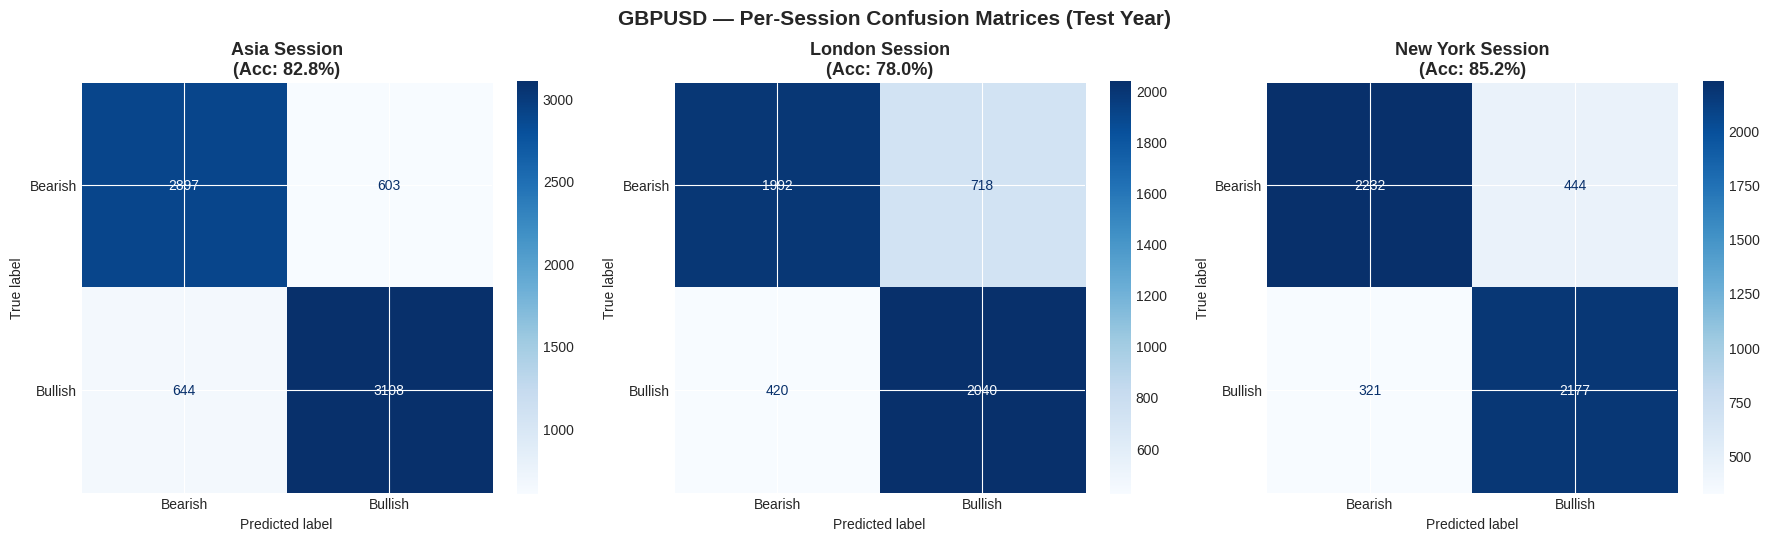

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (sid, sinfo) in enumerate(SESSIONS.items()):
    mask = test_results['session_id'] == sid
    if mask.sum() == 0:
        continue
    y_t = test_results.loc[mask, 'target'].values
    y_p = test_results.loc[mask, 'pred'].values

    cm = confusion_matrix(y_t, y_p)
    s_acc = accuracy_score(y_t, y_p)

    disp = ConfusionMatrixDisplay(cm, display_labels=['Bearish', 'Bullish'])
    disp.plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{sinfo["name"]} Session\n(Acc: {s_acc:.1%})', fontsize=13, fontweight='bold')

plt.suptitle(f'{PAIR} — Per-Session Confusion Matrices (Test Year)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 8D. Per-Session-Instance Accuracy (Majority Vote)

Each session on each day produces multiple 15M predictions. We aggregate them into a single session call using the mean probability method.

In [17]:
# Aggregate predictions per (date, session_id)
session_daily = test_results.groupby(['date', 'session_id']).agg(
    actual=('target', 'first'),
    proba_mean=('proba_bull', 'mean'),
    proba_last=('proba_bull', 'last'),
    n_bars=('pred', 'count'),
).reset_index()

session_daily['pred_mean'] = (session_daily['proba_mean'] > 0.5).astype(int)
session_daily['pred_last'] = (session_daily['proba_last'] > 0.5).astype(int)

print('=' * 65)
print('PER-SESSION-INSTANCE ACCURACY (one call per session per day)')
print('=' * 65)

for sid, sinfo in SESSIONS.items():
    mask = session_daily['session_id'] == sid
    sd = session_daily[mask]
    if len(sd) == 0:
        continue

    acc_mean = accuracy_score(sd['actual'], sd['pred_mean'])
    acc_last = accuracy_score(sd['actual'], sd['pred_last'])

    print(f"\n{'─'*55}")
    print(f"  {sinfo['name'].upper()} ({len(sd)} session instances)")
    print(f"{'─'*55}")
    print(f"  Accuracy (avg proba):  {acc_mean:.4f}  ({acc_mean:.1%})")
    print(f"  Accuracy (last bar):   {acc_last:.4f}  ({acc_last:.1%})")
    print(f"  Actual bullish rate:   {sd['actual'].mean():.1%}")

    print(f"\n  Classification Report (avg proba method):")
    print(classification_report(
        sd['actual'], sd['pred_mean'],
        target_names=['Bearish', 'Bullish'], zero_division=0
    ))


PER-SESSION-INSTANCE ACCURACY (one call per session per day)

───────────────────────────────────────────────────────
  ASIA (259 session instances)
───────────────────────────────────────────────────────
  Accuracy (avg proba):  0.8533  (85.3%)
  Accuracy (last bar):   0.8340  (83.4%)
  Actual bullish rate:   51.7%

  Classification Report (avg proba method):
              precision    recall  f1-score   support

     Bearish       0.85      0.85      0.85       125
     Bullish       0.86      0.86      0.86       134

    accuracy                           0.85       259
   macro avg       0.85      0.85      0.85       259
weighted avg       0.85      0.85      0.85       259


───────────────────────────────────────────────────────
  LONDON (259 session instances)
───────────────────────────────────────────────────────
  Accuracy (avg proba):  0.8031  (80.3%)
  Accuracy (last bar):   0.8687  (86.9%)
  Actual bullish rate:   47.5%

  Classification Report (avg proba method):
      

### 8E. Intraday Probability Traces (Per Session)

How does the model's confidence evolve through each session as new 15M bars arrive?

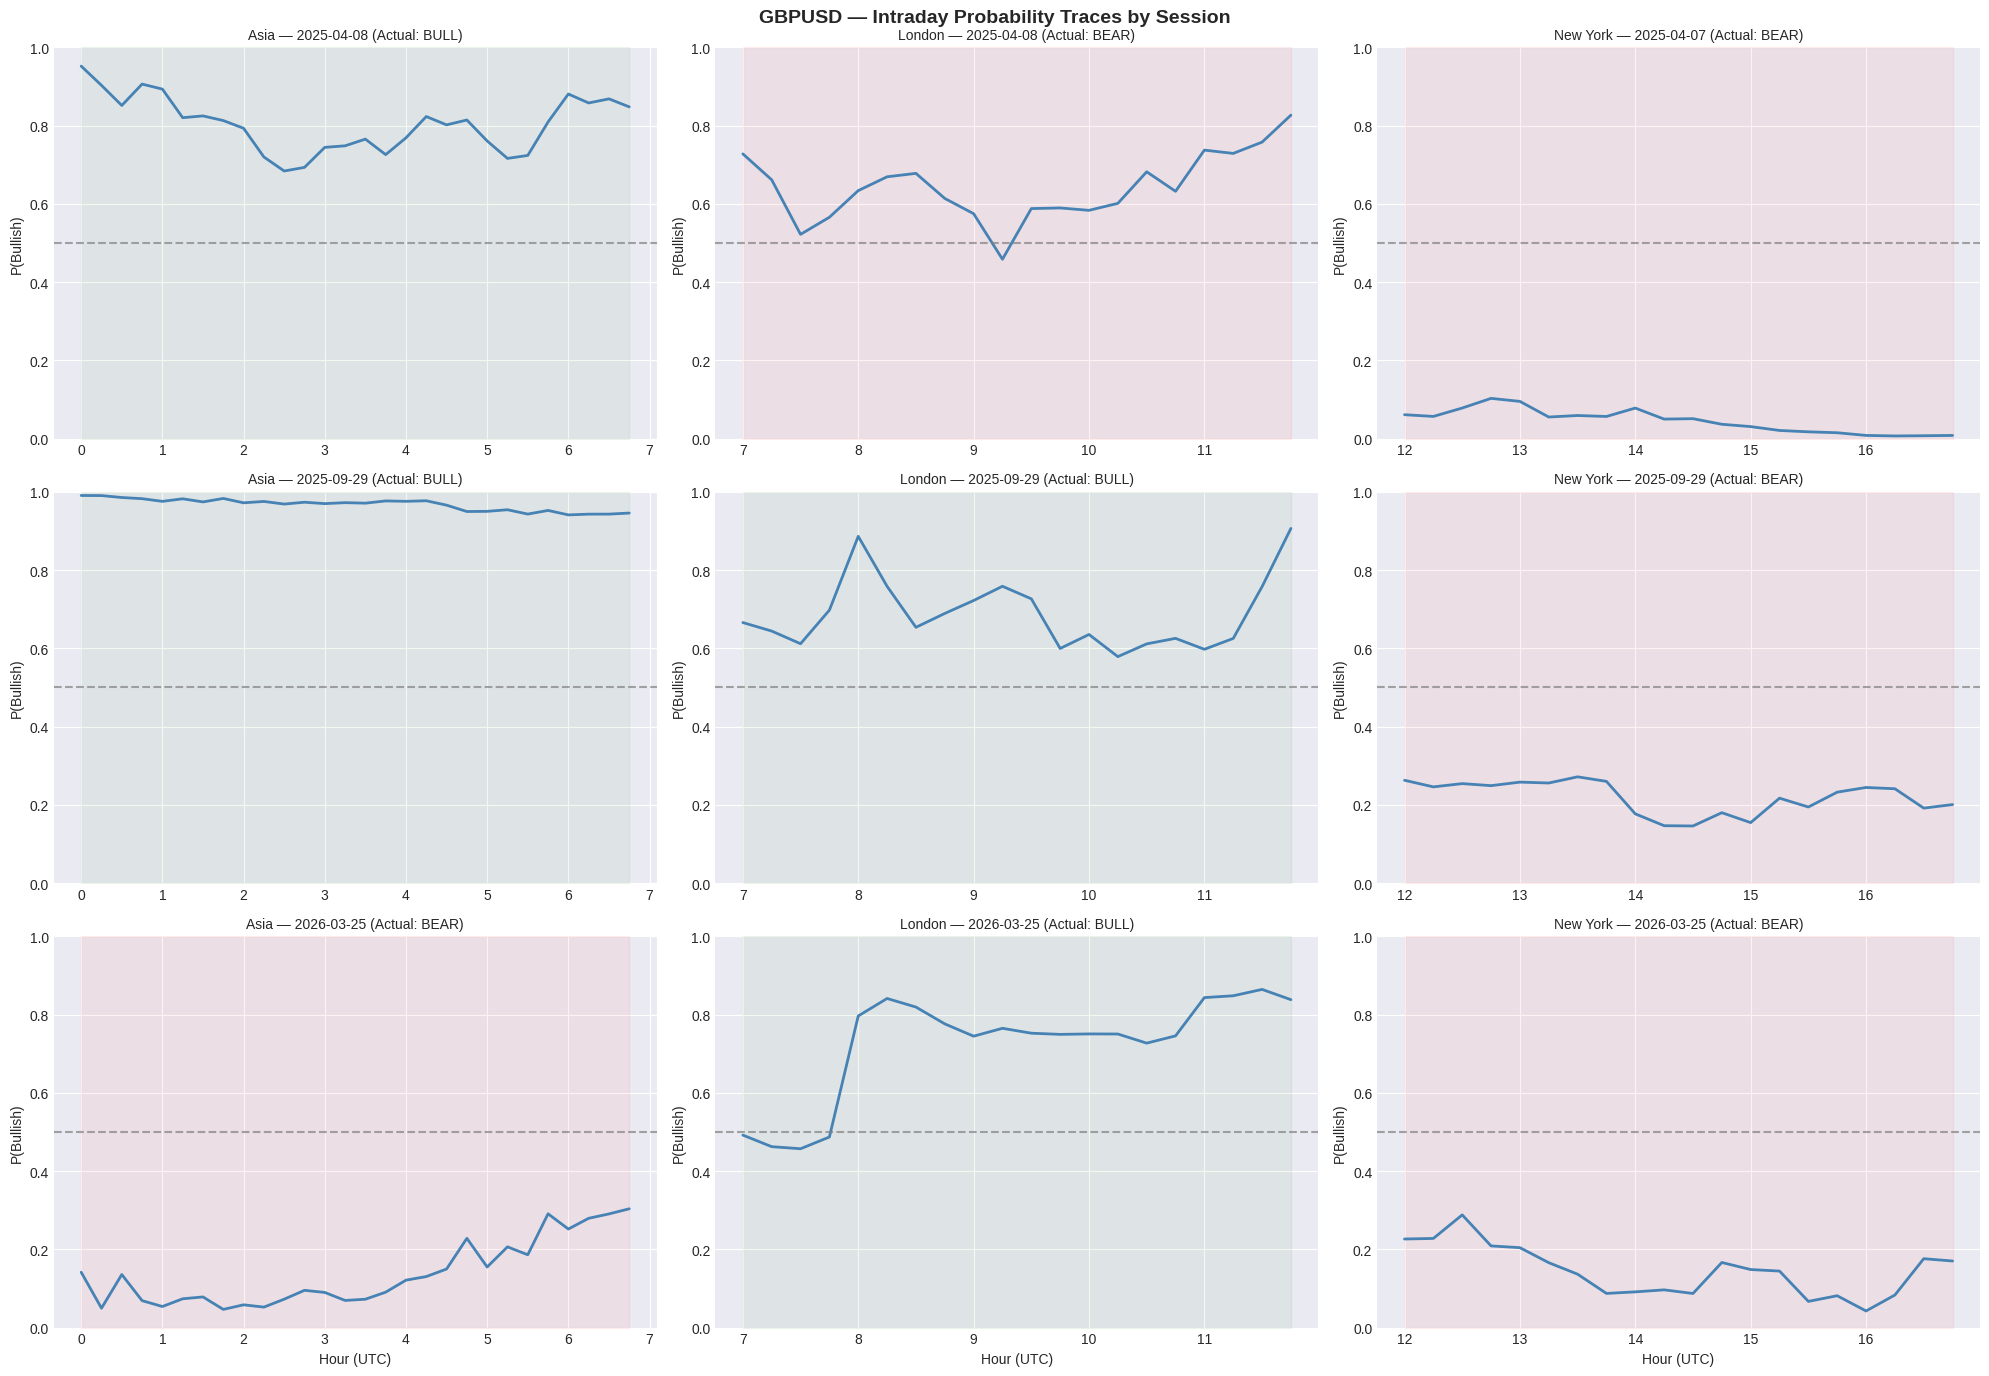

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))

for col_idx, (sid, sinfo) in enumerate(SESSIONS.items()):
    mask = test_results['session_id'] == sid
    session_data = test_results[mask]
    unique_days = sorted(session_data['date'].unique())

    if len(unique_days) < 6:
        continue

    # Pick 3 sample days spread across the test period
    sample_indices = np.linspace(5, len(unique_days) - 5, 3, dtype=int)
    sample_days = [unique_days[i] for i in sample_indices]

    for row_idx, day in enumerate(sample_days):
        ax = axes[row_idx][col_idx]
        day_data = session_data[session_data['date'] == day]
        hours = day_data['datetime'].dt.hour + day_data['datetime'].dt.minute / 60

        actual = day_data['target'].iloc[0]
        color = 'green' if actual == 1 else 'red'
        label = 'BULL' if actual == 1 else 'BEAR'

        ax.plot(hours, day_data['proba_bull'], color='steelblue', linewidth=2)
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
        ax.fill_between(hours, 0, 1, alpha=0.05, color=color)
        ax.set_ylim(0, 1)
        ax.set_title(f'{sinfo["name"]} — {day} (Actual: {label})', fontsize=10)
        ax.set_ylabel('P(Bullish)')
        if row_idx == 2:
            ax.set_xlabel('Hour (UTC)')

plt.suptitle(f'{PAIR} — Intraday Probability Traces by Session', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 9. Trading Performance Per Session

In [19]:
def session_trading_performance(name, daily_df, pred_col='pred_mean'):
    """Simulate trading per session: +1 bullish, -1 bearish."""
    positions = np.where(daily_df[pred_col] == 1, 1, -1).astype(float)
    actual_dir = np.where(daily_df['actual'] == 1, 1, -1).astype(float)
    correct = (positions == actual_dir).astype(int)
    pnl = np.where(correct, 1, -1).astype(float)

    cum_pnl = np.cumsum(pnl)
    equity = 10000 + cum_pnl * 50

    win_rate = correct.mean() * 100
    total_pnl = cum_pnl[-1] * 50 if len(cum_pnl) > 0 else 0

    running_max = np.maximum.accumulate(equity)
    dd = (equity / running_max - 1) * 100
    max_dd = dd.min()

    print(f'\n{"─"*50}')
    print(f'{name} — TRADING PERFORMANCE')
    print(f'{"─"*50}')
    print(f'Win Rate:       {win_rate:.1f}%')
    print(f'Total P&L:      ${total_pnl:+,.0f} (at $50/unit)')
    print(f'Max Drawdown:   {max_dd:.1f}%')
    print(f'Trading Days:   {len(daily_df)}')

    return equity, daily_df['date'].values


# Run for each session
session_equities = {}
for sid, sinfo in SESSIONS.items():
    mask = session_daily['session_id'] == sid
    sd = session_daily[mask].copy().sort_values('date').reset_index(drop=True)
    if len(sd) == 0:
        continue
    eq, dates = session_trading_performance(f'{sinfo["name"]} Session', sd)
    session_equities[sinfo['name']] = (eq, dates)



──────────────────────────────────────────────────
Asia Session — TRADING PERFORMANCE
──────────────────────────────────────────────────
Win Rate:       85.3%
Total P&L:      $+9,150 (at $50/unit)
Max Drawdown:   -1.4%
Trading Days:   259

──────────────────────────────────────────────────
London Session — TRADING PERFORMANCE
──────────────────────────────────────────────────
Win Rate:       80.3%
Total P&L:      $+7,850 (at $50/unit)
Max Drawdown:   -1.4%
Trading Days:   259

──────────────────────────────────────────────────
New York Session — TRADING PERFORMANCE
──────────────────────────────────────────────────
Win Rate:       86.9%
Total P&L:      $+9,600 (at $50/unit)
Max Drawdown:   -1.2%
Trading Days:   260


### 9B. Equity Curves by Session

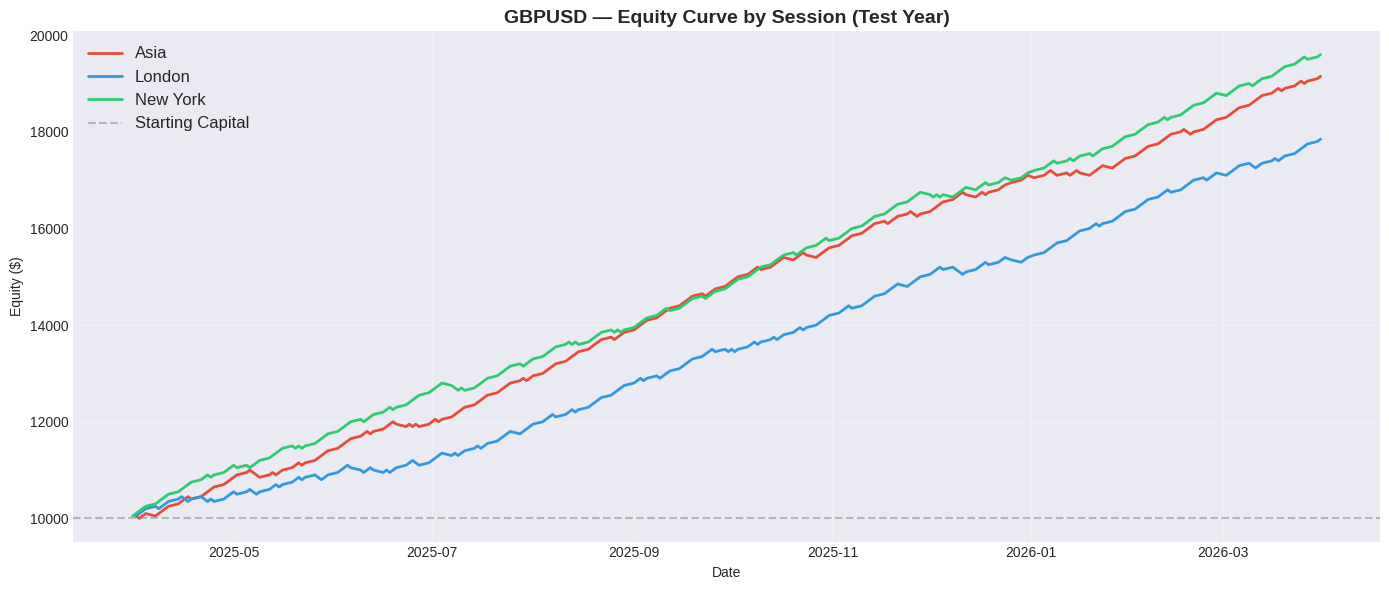

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'Asia': '#e74c3c', 'London': '#3498db', 'New York': '#2ecc71'}
for name, (equity, dates) in session_equities.items():
    ax.plot(dates, equity, label=name, linewidth=2, color=colors.get(name, 'gray'))

ax.axhline(y=10000, color='gray', linestyle='--', alpha=0.5, label='Starting Capital')
ax.set_title(f'{PAIR} — Equity Curve by Session (Test Year)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Equity ($)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 10. Feature Importance

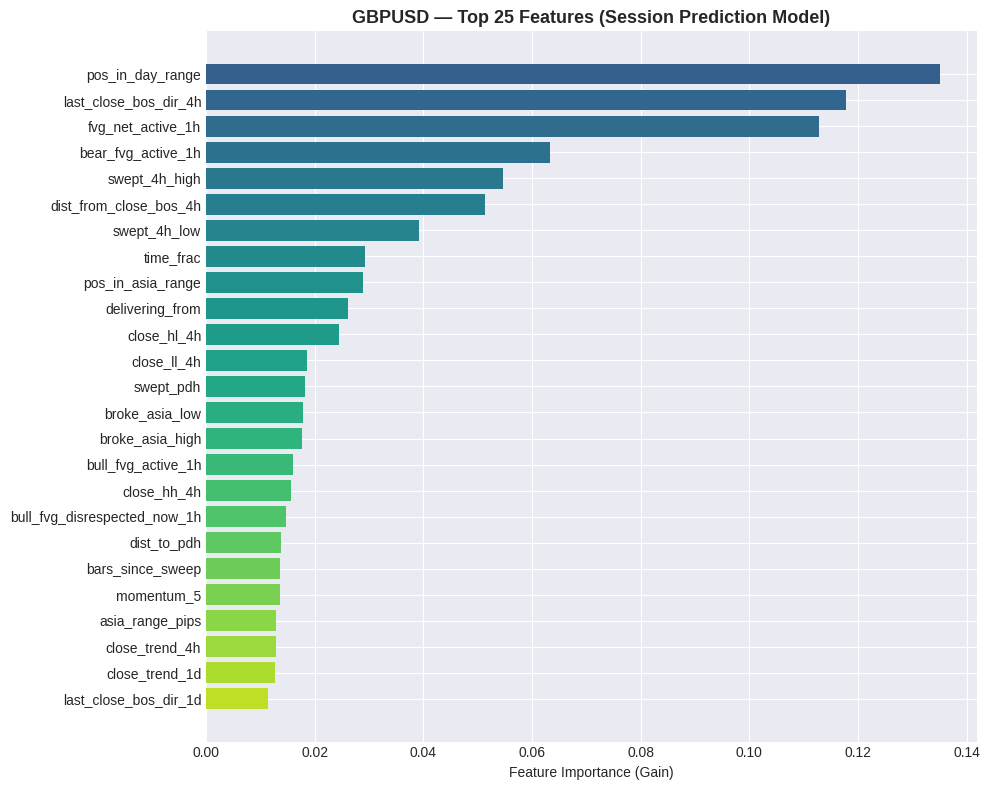


Top 10 features:
   1. pos_in_day_range                     0.1351
   2. last_close_bos_dir_4h                0.1178
   3. fvg_net_active_1h                    0.1129
   4. bear_fvg_active_1h                   0.0632
   5. swept_4h_high                        0.0547
   6. dist_from_close_bos_4h               0.0514
   7. swept_4h_low                         0.0393
   8. time_frac                            0.0293
   9. pos_in_asia_range                    0.0288
  10. delivering_from                      0.0261


In [21]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:25]

fig, ax = plt.subplots(figsize=(10, 8))
top_features = [feature_cols[i] for i in indices]
top_importances = importances[indices]

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
ax.barh(range(len(top_features)), top_importances, color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title(f'{PAIR} — Top 25 Features (Session Prediction Model)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for i, idx in enumerate(indices[:10]):
    print(f"  {i+1:2d}. {feature_cols[idx]:35s}  {importances[idx]:.4f}")


---
## 11. Rolling Accuracy Over Time (Per Session)

Shows how prediction accuracy evolves through the test year with a 20-day rolling window.

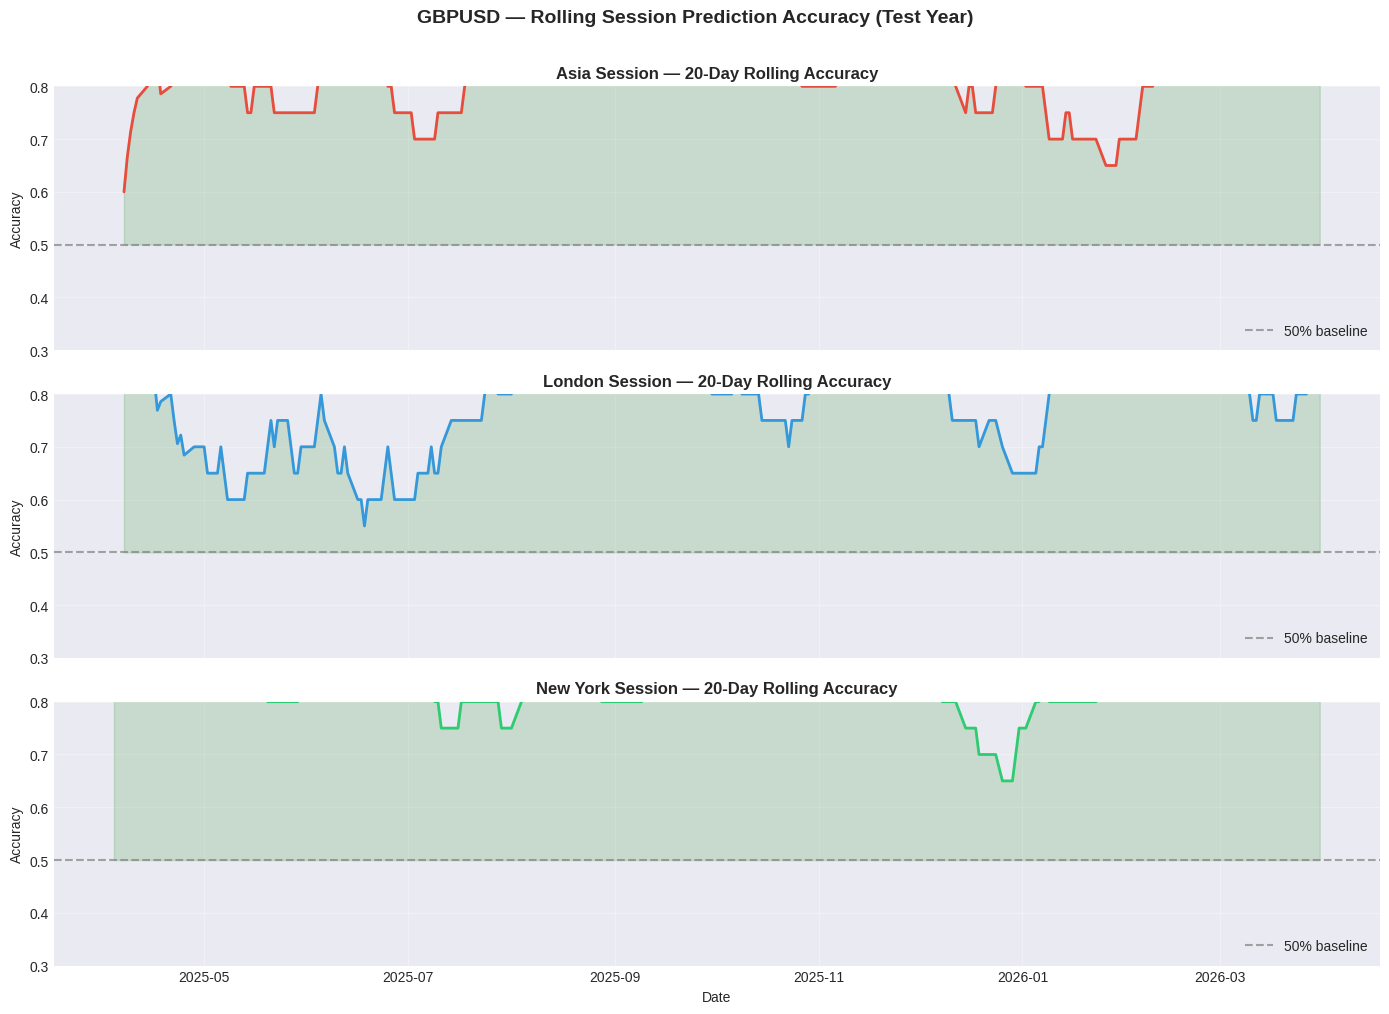

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors = {'Asia': '#e74c3c', 'London': '#3498db', 'New York': '#2ecc71'}

for idx, (sid, sinfo) in enumerate(SESSIONS.items()):
    mask = session_daily['session_id'] == sid
    sd = session_daily[mask].copy().sort_values('date').reset_index(drop=True)
    if len(sd) == 0:
        continue

    sd['correct'] = (sd['pred_mean'] == sd['actual']).astype(int)
    sd['rolling_acc'] = sd['correct'].rolling(20, min_periods=5).mean()

    ax = axes[idx]
    ax.plot(sd['date'].values, sd['rolling_acc'], color=colors[sinfo['name']], linewidth=2)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='50% baseline')
    ax.fill_between(sd['date'].values, 0.5, sd['rolling_acc'],
                     where=sd['rolling_acc'] >= 0.5, alpha=0.15, color='green')
    ax.fill_between(sd['date'].values, 0.5, sd['rolling_acc'],
                     where=sd['rolling_acc'] < 0.5, alpha=0.15, color='red')
    ax.set_ylim(0.3, 0.8)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{sinfo["name"]} Session — 20-Day Rolling Accuracy', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.xlabel('Date')
plt.suptitle(f'{PAIR} — Rolling Session Prediction Accuracy (Test Year)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 12. Summary

### What this notebook tests

This notebook evaluates the XGBoost model from `main.py` on **session-level price movement prediction**:

| Aspect | Detail |
|---|---|
| **Training data** | 4 years of 15M GBPUSD data with full SMC feature engineering |
| **Testing data** | Most recent 1 year (out-of-sample) |
| **Target** | Session close > session open → Bullish (1), else Bearish (0) |
| **Sessions evaluated** | Asia (00–07 UTC), London (07–12 UTC), New York (12–17 UTC) |
| **Evaluation levels** | Per-bar (15M), per-session-instance (daily aggregation) |
| **Metrics** | Accuracy, Precision, Recall, F1, ROC AUC, Brier Score, Confusion Matrices |
| **Trading sim** | Win rate, equity curves, max drawdown per session |

### Key differences from `main.py`

1. **Session-level targets** — predicts each session's direction independently, not just the daily candle
2. **Strict 4yr/1yr split** — no 80/20 ratio; uses calendar-based cutoff for realistic backtesting
3. **Per-session evaluation** — identifies which sessions the model predicts best
4. **Rolling accuracy** — shows model stability over time
